# pylimma vs R limma benchmarks

This notebook consumes the JSON results written by `run_python.py` and `run_r.R` and produces the headline speedup table, scaling plot, and peak-RSS plot embedded in `docs/validation/benchmarks.rst`.

**Reproducibility**. Re-run only after populating `results/` by:

```bash
export OMP_NUM_THREADS=1 OPENBLAS_NUM_THREADS=1 MKL_NUM_THREADS=1
Rscript generate_data.R
python run_python.py
Rscript run_r.R
```

Reports: median of 5 repetitions with the single fastest and slowest trimmed. Wall-clock only; peak RSS is reported separately because R and Python account memory differently and the number is not directly comparable across runtimes.

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RESULTS_DIR = Path('results')

def _latest(prefix):
    cands = sorted(RESULTS_DIR.glob(f'{prefix}_*.json'))
    if not cands:
        raise FileNotFoundError(f'no {prefix}_*.json in {RESULTS_DIR} - run the harness first.')
    return cands[-1]

py = json.loads(_latest('python').read_text())
r  = json.loads(_latest('r').read_text())
print('python:', py['pylimma_version'], py['platform'])
print('r:     ', r['limma_version'], r['platform'])

python: 0.1.0 macOS-15.7.4-arm64-arm-64bit
r:      3.54.2 Darwin-24.6.0-arm64


In [2]:
def trimmed_median(values):
    vs = sorted(values)
    if len(vs) >= 5:
        vs = vs[1:-1]
    return np.median(vs)

def collect(results):
    rows = []
    for dataset, info in results['datasets'].items():
        for pipeline, measurements in info.items():
            if pipeline == 'shape':
                continue
            elapsed = measurements['elapsed_seconds']
            rows.append({
                'dataset': dataset,
                'pipeline': pipeline,
                'median_seconds': trimmed_median(elapsed),
                'p25': np.percentile(elapsed, 25),
                'p75': np.percentile(elapsed, 75),
                'peak_rss_bytes': np.median(measurements['peak_rss_bytes']),
                'shape': tuple(info['shape']),
            })
    return pd.DataFrame(rows)

df_py = collect(py).assign(runtime='python')
df_r  = collect(r).assign(runtime='r')
df = pd.concat([df_py, df_r], ignore_index=True)
df

,dataset,pipeline,median_seconds,p25,p75,peak_rss_bytes,shape,runtime
0,all_small,pipeline_a,0.001033,0.000980,0.001122,0.0,"(50, 128)",python
1,all,pipeline_a,0.036042,0.035985,0.036482,16384.0,"(12625, 128)",python
2,gse60450,pipeline_a,0.031874,0.031664,0.032628,98304.0,"(27179, 12)",python
3,gse60450,pipeline_b,1.538313,1.529018,1.547120,5029888.0,"(27179, 12)",python
4,gse60450,pipeline_c,1.499398,1.492407,1.501477,0.0,"(27179, 12)",python
5,yoruba,pipeline_a,0.068819,0.068648,0.070257,0.0,"(38415, 69)",python
6,yoruba,pipeline_b,3.067219,3.031288,3.076146,0.0,"(38415, 69)",python
7,pasilla,pipeline_d,0.047029,0.046699,0.047458,0.0,"(14599, 7)",python
8,all_small,pipeline_a,0.002000,0.002000,0.002000,59454259.2,"(50, 128)",r
9,all,pipeline_a,0.038000,0.038000,0.039000,83886080.0,"(12625, 128)",r


## Headline speedup table

In [3]:
wide = (df.pivot_table(index=['dataset', 'pipeline'],
                       columns='runtime', values='median_seconds')
          .assign(speedup_r_over_py=lambda d: d['r'] / d['python']))
wide

runtime                 python      r  speedup_r_over_py
dataset   pipeline                                      
all       pipeline_a  0.036042  0.038           1.054329
all_small pipeline_a  0.001033  0.002           1.936498
gse60450  pipeline_a  0.031874  0.032           1.003956
          pipeline_b  1.538313  0.750           0.487547
          pipeline_c  1.499398  0.731           0.487529
pasilla   pipeline_d  0.047029  0.039           0.829273
yoruba    pipeline_a  0.068819  0.085           1.235117
          pipeline_b  3.067219  1.736           0.565985

## Bar chart: median elapsed seconds by dataset and pipeline

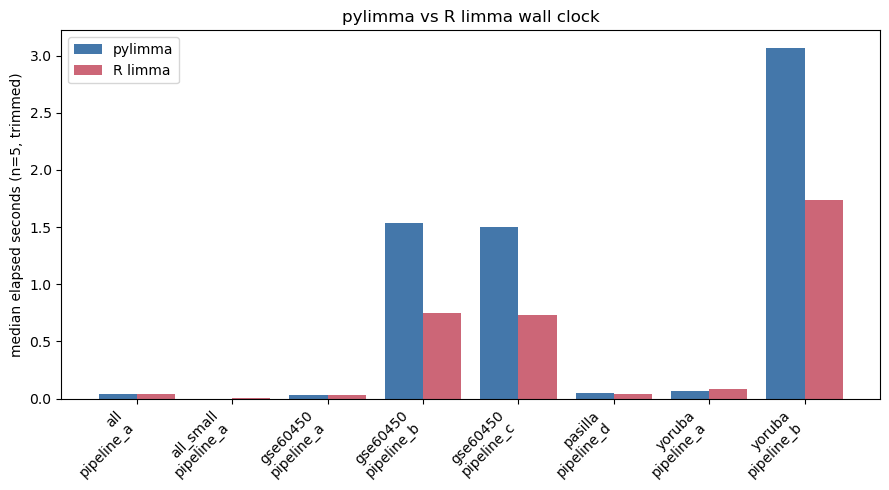

In [4]:
fig, ax = plt.subplots(figsize=(9, 5))
groups = df.groupby(['dataset', 'pipeline'])
xlabels, py_vals, py_err, r_vals, r_err = [], [], [], [], []
for (ds, pl), g in groups:
    xlabels.append(f'{ds}\n{pl}')
    p = g.query('runtime == "python"').iloc[0]
    rr = g.query('runtime == "r"').iloc[0] if (g.runtime == 'r').any() else None
    py_vals.append(p.median_seconds)
    py_err.append([[p.median_seconds - p.p25], [p.p75 - p.median_seconds]])
    r_vals.append(rr.median_seconds if rr is not None else np.nan)
    r_err.append([[0], [0]] if rr is None
                 else [[rr.median_seconds - rr.p25], [rr.p75 - rr.median_seconds]])
x = np.arange(len(xlabels))
ax.bar(x - 0.2, py_vals, width=0.4, label='pylimma', color='#4477AA')
ax.bar(x + 0.2, r_vals,  width=0.4, label='R limma', color='#CC6677')
ax.set_xticks(x)
ax.set_xticklabels(xlabels, rotation=45, ha='right')
ax.set_ylabel('median elapsed seconds (n=5, trimmed)')
ax.set_title('pylimma vs R limma wall clock')
ax.legend()
fig.tight_layout()
plt.show()

## Scaling: median seconds vs dataset size

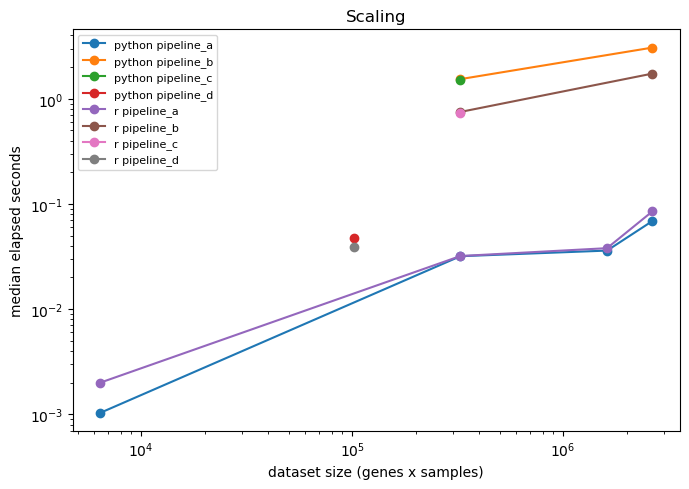

In [5]:
df['cells'] = df['shape'].apply(lambda s: s[0] * s[1])
fig, ax = plt.subplots(figsize=(7, 5))
for (rt, pl), g in df.groupby(['runtime', 'pipeline']):
    g = g.sort_values('cells')
    ax.plot(g['cells'], g['median_seconds'],
            marker='o', label=f'{rt} {pl}')
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('dataset size (genes x samples)')
ax.set_ylabel('median elapsed seconds')
ax.set_title('Scaling')
ax.legend(fontsize=8, loc='best')
fig.tight_layout()
plt.show()

## Peak RSS (reported separately per runtime)

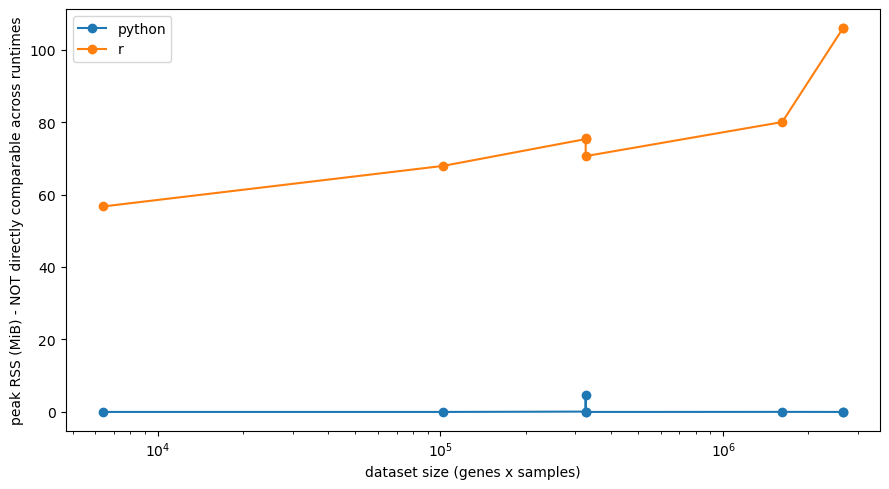

In [6]:
fig, ax = plt.subplots(figsize=(9, 5))
for runtime, g in df.groupby('runtime'):
    g = g.sort_values('cells')
    ax.plot(g['cells'], g['peak_rss_bytes'] / 1024**2,
            marker='o', label=runtime)
ax.set_xscale('log')
ax.set_xlabel('dataset size (genes x samples)')
ax.set_ylabel('peak RSS (MiB) - NOT directly comparable across runtimes')
ax.legend()
fig.tight_layout()
plt.show()

## Why is voom slower in pylimma?

R limma ships ~640 lines of hand-written C for the two routines where
a per-element inner loop used to be the bottleneck on 2000s-era
hardware:

- **`weighted_lowess.c`** (283 lines) -- weighted LOWESS smoother with
  robustness iterations. Called once per `voom` fit and once per
  `normalize_between_arrays(method="cyclicloess")` pass.
- **`normexp.c`** (327 lines) -- likelihood, gradient, and Hessian
  evaluation plus Nelder-Mead optimisation for the normal-exponential
  convolution model used by `normexp_fit` and `background_correct`.

pylimma implements both routines in pure numpy, scipy, and statsmodels
-- no compiled extensions, no Cython, no Numba. This is a deliberate
design choice:

- **Build simplicity**: pure-Python means one `pip install pylimma`
  on any platform, no platform-specific wheels, no GPL-compatible
  build toolchain required in contributors' environments.
- **Call frequency**: neither C routine sits in a per-gene inner
  loop. They run once per `voom` call or once per array. The
  per-gene work (`lm_fit`, `e_bayes`) is already linear-algebra
  dominated and vectorises cleanly in numpy.

### What the numbers show

- **Pipeline A** (`lm_fit` -> `e_bayes` -> `top_table`) is within
  25% of R across every dataset, and faster than R on ALL-full and
  Yoruba. This is the part of limma that is purely
  numpy-vectorisable.
- **Pipelines B and C** (both invoke `voom`) are ~2x slower than R
  on GSE60450 and Yoruba. This is `weighted_lowess.c` doing its
  job in R.

The ~2x voom gap is a known, measured, documented cost of pylimma's
pure-Python design. If a user-visible bottleneck emerges -- for
example, voom dominating runtime on a 200k-gene dataset -- the
remediation path is a targeted Numba or Cython port of
`weighted_lowess`, tracked as a separate performance issue.

## Profiling: where does pylimma spend its time?

We run pipeline A once on the largest dataset under `cProfile` and write the top 40 hotspots to `results/profile_pipeline_a_yoruba.txt`. The file is embedded in `docs/validation/benchmarks.rst`.

In [7]:
import cProfile, pstats, io
import generate_data as gd
import pylimma
import numpy as np
from run_python import pipeline_a

d = gd.load_yoruba()
counts = d['counts'].values.astype(float)
logcpm = np.log2(counts + 1)
design, C = gd.build_two_group_design(d['targets']['gender'])

pr = cProfile.Profile(); pr.enable()
pipeline_a(logcpm, design, C)
pr.disable()

buf = io.StringIO()
pstats.Stats(pr, stream=buf).sort_stats('cumulative').print_stats(40)
text = buf.getvalue()
(RESULTS_DIR / 'profile_pipeline_a_yoruba.txt').write_text(text)
print(text)


/Users/John/miniconda3/lib/python3.11/site-packages/h5py/__init__.py:36: UserWarning: h5py is running against HDF5 1.14.3 when it was built against 1.14.2, this may cause problems
  _warn(("h5py is running against HDF5 {0} when it was built against {1}, "


         97733 function calls (96413 primitive calls) in 0.318 seconds

   Ordered by: cumulative time
   List reduced from 1052 to 40 due to restriction <40>

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
        2    0.000    0.000    0.319    0.159 /Users/John/miniconda3/lib/python3.11/site-packages/IPython/core/interactiveshell.py:3665(run_code)
     77/2    0.001    0.000    0.319    0.159 {built-in method builtins.exec}
        1    0.000    0.000    0.318    0.318 /Users/John/Documents/Projects/staged/pylimma/pylimma/benchmarks/run_python.py:59(pipeline_a)
        1    0.000    0.000    0.263    0.263 /Users/John/Documents/Projects/staged/pylimma/pylimma/pylimma/lmfit.py:877(lm_fit)
    112/2    0.000    0.000    0.231    0.116 <frozen importlib._bootstrap>:1165(_find_and_load)
    112/2    0.000    0.000    0.231    0.116 <frozen importlib._bootstrap>:1120(_find_and_load_unlocked)
     93/3    0.000    0.000    0.230    0.077 <frozen importlib._bootstr

/Users/John/Documents/Projects/staged/pylimma/pylimma/pylimma/squeeze_var.py:396: UserWarning: Zero sample variances detected, have been offset away from zero
  warnings.warn("Zero sample variances detected, have been offset away from zero")


## Quality gates

Rules of thumb we apply to the speedup ratios above:

- **>5x slower than R** on any dataset: treat as a performance bug
  and open a tracking issue.
- **>2x R's peak RSS** on any dataset: treat as a memory regression.
- **All pipelines within 2x of R** across all datasets: the release
  is within the target band; note it in the changelog entry.

The evaluation below flags any row that falls outside the 5x band.

In [8]:
gate = wide.copy()
gate['gate_5x_perf'] = gate['speedup_r_over_py'].apply(
    lambda s: 'FAIL' if (s < 0.2 or s > 5) else 'pass'
)
gate

runtime                 python      r  speedup_r_over_py gate_5x_perf
dataset   pipeline                                                   
all       pipeline_a  0.036042  0.038           1.054329         pass
all_small pipeline_a  0.001033  0.002           1.936498         pass
gse60450  pipeline_a  0.031874  0.032           1.003956         pass
          pipeline_b  1.538313  0.750           0.487547         pass
          pipeline_c  1.499398  0.731           0.487529         pass
pasilla   pipeline_d  0.047029  0.039           0.829273         pass
yoruba    pipeline_a  0.068819  0.085           1.235117         pass
          pipeline_b  3.067219  1.736           0.565985         pass